# 12. Ablation study

**Question: which components are actually load-bearing?**

Every previous notebook added something: regularization, subsampling, class weighting, a
learned threshold. A stack of additions that each looked reasonable in isolation is
exactly the kind of thing that hides a component doing nothing at all.

This notebook removes them one at a time from the XGBoost pipeline and measures what the
removal costs. The chart is deliberately signed — bars to the right are components whose
removal made things **worse** (so they were earning their place), bars to the left are
components whose removal made things **better**.

The most important row is the last one: replacing the learned threshold with `0.5`. That
isolates how much of the result comes from the model versus from the decision rule.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.studies import run_xgboost_ablation

ablation = run_xgboost_ablation(TRAIN, TEST, ARTIFACTS)
ablation

,ablation,threshold,total_cost,cost_per_observation,false_positives,false_negatives,precision,recall,pr_auc,roc_auc,always_negative_cost,always_positive_cost,saving_vs_always_negative,saving_vs_always_positive,score_kind,brier,log_loss
0,full,0.004870,11050.0,0.690625,855,5,0.302041,0.986667,0.932325,0.996019,187500.0,156250.0,176450.0,145200.0,probability,0.005053,0.018832
1,no_l1_l2,0.004675,9580.0,0.598750,758,4,0.328609,0.989333,0.930117,0.996091,187500.0,156250.0,177920.0,146670.0,probability,0.004967,0.018876
2,no_subsampling,0.005444,10620.0,0.663750,912,3,0.289720,0.992000,0.929636,0.995611,187500.0,156250.0,176880.0,145630.0,probability,0.005178,0.019460
3,no_class_weight,0.020467,11360.0,0.710000,286,17,0.555901,0.954667,0.930060,0.995823,187500.0,156250.0,176140.0,144890.0,probability,0.004995,0.019604
4,threshold_0_5,0.500000,26010.0,1.625625,51,51,0.864000,0.864000,0.932325,0.996019,187500.0,156250.0,161490.0,130240.0,probability,0.005053,0.018832


,total_cost,change_vs_full,relative_change
ablation,,,
threshold_0_5,26010.0,14960.0,1.353846
no_class_weight,11360.0,310.0,0.028054
no_subsampling,10620.0,-430.0,-0.038914
no_l1_l2,9580.0,-1470.0,-0.133032


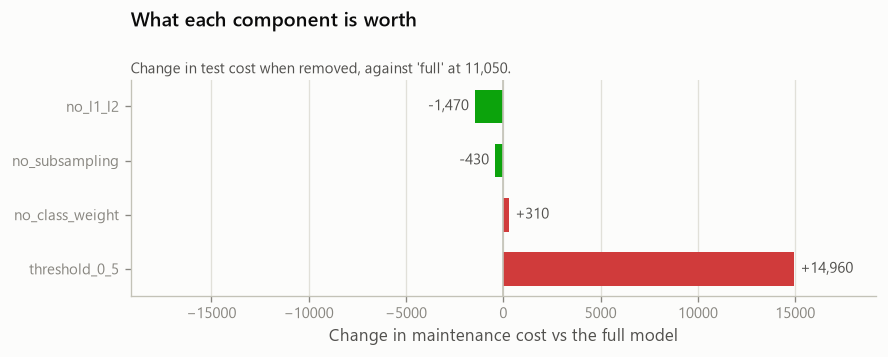

In [3]:
from scania_aps.plotting import diverging_bars

label_column = "ablation" if "ablation" in ablation.columns else ablation.columns[0]
indexed = ablation.set_index(label_column)

# The reference row is the untouched pipeline; everything else is a delta from it.
reference_name = next(
    (n for n in indexed.index if str(n).lower() in {"full", "baseline", "all", "complete"}),
    indexed["total_cost"].idxmin(),
)
reference = indexed.loc[reference_name, "total_cost"]

deltas = indexed.drop(index=reference_name)["total_cost"] - reference
deltas = deltas.sort_values()

fig, ax = diverging_bars(
    [str(i) for i in deltas.index],
    [float(v) for v in deltas.to_numpy()],
    title="What each component is worth",
    semantic=True,
    subtitle=f"Change in test cost when removed, against '{reference_name}' at {reference:,.0f}.",
)

pd.DataFrame(
    {
        "total_cost": indexed.drop(index=reference_name)["total_cost"],
        "change_vs_full": deltas,
        "relative_change": deltas / reference,
    }
).sort_values("change_vs_full", ascending=False)

### Reading the result

The threshold row dominates everything else, and not by a little. Replacing the learned
operating point with `0.5` costs more than every other component in the pipeline
combined — the same conclusion [notebook 10](10_threshold_optimization.ipynb) reached
from the opposite direction, now measured against a full model rather than a bare score.

**The regularization rows are the uncomfortable ones.** Removing the L1/L2 leaf
penalties does not cost anything; it *saves*. So does dropping the row and column
subsampling. On this data, at this sample size, the boosting model was not
variance-limited, and the regularization as configured was shrinking away signal it
needed.

Two readings are available and they are not the same claim:

- **"Regularization is useless here."** Too strong. What is measured is one setting of
  `reg_alpha`/`reg_lambda` on one split — a weaker penalty might beat both.
- **"These penalties are mistuned."** Supported, and actionable. The honest response is
  to fold the penalty strengths into the search in
  [notebook 06](06_gradient_boosting.ipynb) rather than fixing them by default.

Either way the ablation has done its job: it found a component that was quietly costing
money. A stack of individually-plausible additions is exactly where that hides, and only
removing them one at a time exposes it.

One caution before acting on any of this: these are single-split differences with no
confidence interval. The threshold row is far too large to be noise. The regularization
rows, at a few percent, are not obviously outside it.

**Next:** [13 — final model comparison](13_final_model_comparison.ipynb).